
# Olympics Medals vs Economy

**Goal:** Examine how countries' medal counts at the Summer Olympics 2024 relate to GDP per capita and population.

**Pipeline:** API (World Bank) + static web scraping (Wikipedia medal table) -> cleaning/merging -> EDA -> visualizations.



## Data Sources

- Wikipedia medal table (Summer Olympics 2024): `https://en.wikipedia.org/wiki/2024_Summer_Olympics_medal_table`  
- World Bank API: GDP per capita (NY.GDP.PCAP.CD), Population (SP.POP.TOTL)  
- World Bank countries metadata (regions)



## Environment


In [ ]:

import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import json



## Scrape: Wikipedia Medal Table (Static Page)
Parses the medal table (Gold, Silver, Bronze, Total) for Paris 2024.


In [ ]:

WIKI_URL = "https://en.wikipedia.org/wiki/2024_Summer_Olympics_medal_table"

r = requests.get(WIKI_URL, headers={"User-Agent": "Mozilla/5.0"})
soup = BeautifulSoup(r.text, "html.parser")
tables = soup.find_all("table", {"class": "wikitable"})
target = None
for t in tables:
    ths = [th.get_text(strip=True) for th in t.find_all("th")]
    if {"Gold","Silver","Bronze"}.issubset(set(ths)):
        target = t
        break
rows = []
for tr in target.find_all("tr"):
    tds = [td.get_text(" ", strip=True) for td in tr.find_all(["td","th"])]
    if len(tds) < 5:
        continue
    if "Gold" in tds and "Silver" in tds and "Bronze" in tds:
        continue
    if any(x in tds[0].lower() for x in ["rank","noc","nation","team/noc","team"]):
        continue
    rows.append(tds)
df = pd.DataFrame(rows)
col_candidates = ["Rank","Nation","Gold","Silver","Bronze","Total"]
if df.shape[1] >= 6:
    df = df.iloc[:, :6]
    df.columns = col_candidates
for c in ["Gold","Silver","Bronze","Total"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Nation"] = df["Nation"].str.replace(r"\[.*?\]","",regex=True).str.strip()
df = df.dropna(subset=["Gold","Silver","Bronze"])
df["medals_total"] = df["Total"].fillna(0).astype(float)
df = df[["Nation","Gold","Silver","Bronze","medals_total"]]
medals = df


medals.head(100)


,Nation,Gold,Silver,Bronze,medals_total
0,United States ‡,40,44,42.0,126.0
1,China,40,27,24.0,91.0
2,Japan,20,12,13.0,45.0
3,Australia,18,19,16.0,53.0
4,France *,16,26,22.0,64.0
...,...,...,...,...,...
86,0,0,1,1.0,0.0
87,0,0,1,1.0,0.0
88,0,0,1,1.0,0.0
89,0,0,1,1.0,0.0



## API: World Bank Countries + Indicators


In [ ]:

WB_COUNTRIES = "https://api.worldbank.org/v2/country?per_page=400&format=json"
WB_INDICATOR = "https://api.worldbank.org/v2/country/{codes}/indicator/{ind}?date={y1}:{y2}&format=json&per_page=20000"


data = requests.get(WB_COUNTRIES).json()

items = data[1]
c = pd.DataFrame(items)
c = c.rename(columns={"id":"iso3","name":"wb_name"})
c["region_name"] = c["region"].apply(lambda x: x.get("value") if isinstance(x,dict) else None)

countries = c[["iso3","wb_name","region_name"]]

countries.head()


,iso3,wb_name,region_name
0,ABW,Aruba,Latin America & Caribbean
1,AFE,Africa Eastern and Southern,Aggregates
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan"
3,AFR,Africa,Aggregates
4,AFW,Africa Western and Central,Aggregates



## Cleaning and Name Mapping
Map Wikipedia country names to World Bank ISO3 where necessary.


In [ ]:

manual_map = {
    "United States": "United States",
    "Great Britain": "United Kingdom",
    "Czech Republic": "Czechia",
    "Iran": "Iran, Islamic Rep.",
    "Hong Kong, China": "Hong Kong SAR, China",
    "Chinese Taipei": "Taiwan, China",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Russia": "Russian Federation",
    "Kosovo": "Kosovo",
    "Vietnam": "Vietnam",
    "Syria": "Syrian Arab Republic",
    "Moldova": "Moldova",
    "Ivory Coast": "Cote d'Ivoire",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "DR Congo": "Congo, Dem. Rep.",
    "Congo": "Congo, Rep.",
    "Bolivia": "Bolivia",
    "Venezuela": "Venezuela, RB",
    "Tanzania": "Tanzania",
    "Laos": "Lao PDR",
    "Brunei": "Brunei Darussalam",
    "Cape Verde": "Cabo Verde",
    "Bahamas": "Bahamas, The",
    "Micronesia": "Micronesia, Fed. Sts.",
    "Macao, China": "Macao SAR, China",
    "Trinidad and Tobago": "Trinidad and Tobago",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Eswatini": "Eswatini",
    "Timor-Leste": "Timor-Leste"
}

m = medals.copy()
m["wb_name"] = m["Nation"].replace(manual_map)
merged_try = pd.merge(m, countries, left_on="wb_name", right_on="wb_name", how="left")
missing = merged_try[merged_try["iso3"].isna()][["Nation","wb_name"]].drop_duplicates()
missing.head()


,Nation,wb_name
0,United States ‡,United States ‡
4,France *,France *
22,Romania ‡,Romania ‡
30,2,2
34,Chinese Taipei,"Taiwan, China"


In [ ]:
def get_indicator(iso3_list, indicator, y1=2020, y2=2024):
    out = []
    if not iso3_list:
        return pd.DataFrame(columns=["iso3", indicator])
    chunks = [iso3_list[i:i+50] for i in range(0, len(iso3_list), 50)]
    for chunk in chunks:
        codes = ";".join([c.lower() for c in chunk])
        url = WB_INDICATOR.format(codes=codes, ind=indicator, y1=y1, y2=y2)
        data = requests.get(url).json()
        rows = data[1] if isinstance(data, list) and len(data) > 1 else []
        for r in rows:
            v = r.get("value", None)
            c3 = r.get("countryiso3code", None)
            if v is None or not c3:
                continue
            out.append({"iso3": c3.upper(), "year": int(r["date"]), indicator: v})
    df = pd.DataFrame(out)
    if df.empty:
        return pd.DataFrame(columns=["iso3", indicator])
    df = df.sort_values(["iso3","year"]).groupby("iso3", as_index=False).tail(1)
    return df[["iso3", indicator]]

In [ ]:
medals_iso = pd.merge(m, countries, on="wb_name", how="left")
medals_iso = medals_iso.dropna(subset=["iso3"])

iso3_list = medals_iso["iso3"].unique().tolist()
gdp_pc = get_indicator(iso3_list, "NY.GDP.PCAP.CD", 2020, 2024)
pop    = get_indicator(iso3_list, "SP.POP.TOTL",    2020, 2024)

df = medals_iso.merge(gdp_pc, on="iso3", how="left").merge(pop, on="iso3", how="left")
df = df.rename(columns={"NY.GDP.PCAP.CD":"gdp_per_capita","SP.POP.TOTL":"population"})

if "region_name" in df.columns:
    pass
elif set(["region_name_x","region_name_y"]).issubset(df.columns):
    df["region_name"] = df["region_name_x"].fillna(df["region_name_y"])
    df = df.drop(columns=["region_name_x","region_name_y"])
else:
    df = df.merge(countries[["iso3","region_name"]], on="iso3", how="left")

df["population_million"] = df["population"]/1e6
df["medals_per_million"] = df["medals_total"]/df["population_million"]


In [ ]:
print(gdp_pc.head())
print(pop.head())
print(df[["wb_name","iso3","gdp_per_capita","population"]].head())
print(df[df["gdp_per_capita"].isna()].shape, "rows with missing GDPpc")


    iso3  NY.GDP.PCAP.CD
243  ALB    10011.627986
0    ARG    13858.203980
5    ARM     8500.605225
10   AUS    64407.484257
15   AUT    56833.196047
    iso3  SP.POP.TOTL
250  ALB      2714617
0    ARG     45696159
5    ARM      3033500
10   AUS     27204809
15   AUT      9178482
          wb_name iso3  gdp_per_capita  population
0           China  CHN    13303.148154  1408975000
1           Japan  JPN    32475.892499   123975371
2       Australia  AUS    64407.484257    27204809
3     Netherlands  NLD    68218.726102    17994237
4  United Kingdom  GBR    52636.786594    69226000
(0, 12) rows with missing GDPpc



## Basic EDA


In [ ]:

summary = df[["medals_total","gdp_per_capita","population","medals_per_million"]].describe()
summary


,medals_total,gdp_per_capita,population,medals_per_million
count,56.000000,56.000000,5.600000e+01,56.000000
mean,13.339286,28248.547218,7.971281e+07,1.118125
std,17.248217,26422.644832,2.654422e+08,2.044819
min,1.000000,1011.073324,6.620500e+04,0.004135
25%,4.000000,7537.995843,5.369818e+06,0.308532
50%,7.000000,15785.178046,1.079190e+07,0.719010
75%,12.250000,42356.288853,4.597570e+07,1.335210
max,91.000000,107316.337307,1.450936e+09,15.104599



## Visualizations

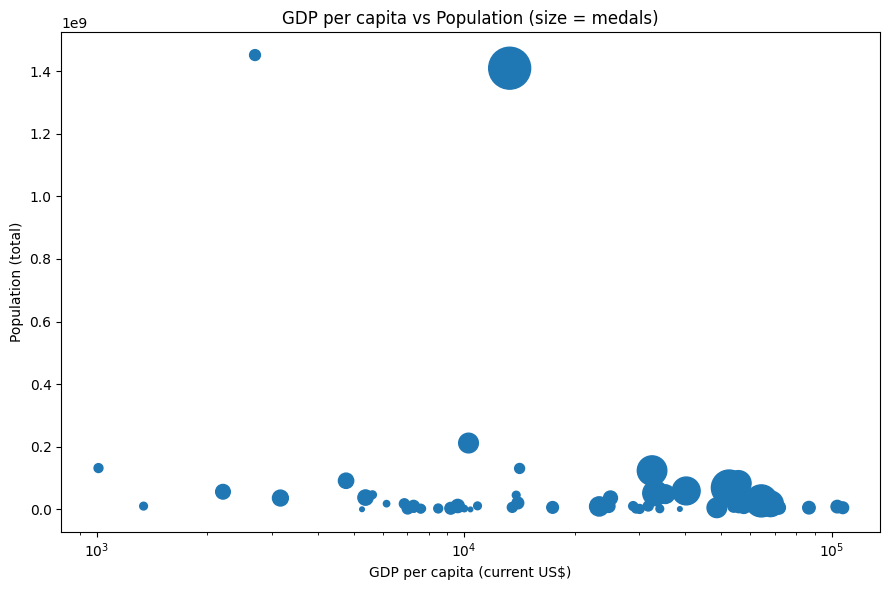

In [ ]:
plt.figure(figsize=(9,6))
s = (df["medals_total"].fillna(0) + 0.1) * 10
plt.scatter(df["gdp_per_capita"], df["population"], s=s)
plt.xscale("log")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("Population (total)")
plt.title("GDP per capita vs Population (size = medals)")
plt.tight_layout()
plt.savefig("fig1_bubble_gdp_pop.png", dpi=200)
plt.show()

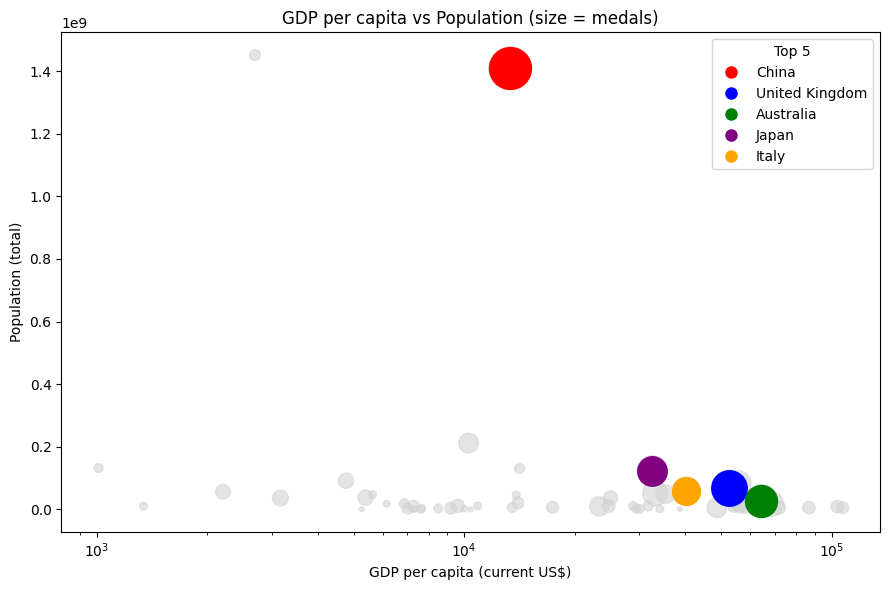

In [ ]:
top_5_medals = df.sort_values("medals_total", ascending=False).head(5)

plt.figure(figsize=(9,6))
s = (df["medals_total"].fillna(0) + 0.1) * 10
plt.scatter(df["gdp_per_capita"], df["population"], s=s, color='lightgray', alpha=0.6)

colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, (_, row) in enumerate(top_5_medals.iterrows()):
    plt.scatter(row["gdp_per_capita"], row["population"], s=(row["medals_total"] + 0.1) * 10, color=colors[i], label="_nolegend_")

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker='o', linestyle='', color=colors[i], label=top_5_medals.iloc[i]["wb_name"], markersize=8) for i in range(len(top_5_medals))
]

plt.xscale("log")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("Population (total)")
plt.title("GDP per capita vs Population (size = medals)")
plt.legend(handles=handles, title="Top 5")
plt.tight_layout()
plt.savefig("fig1_bubble_gdp_pop_top5.png", dpi=200)
plt.show()


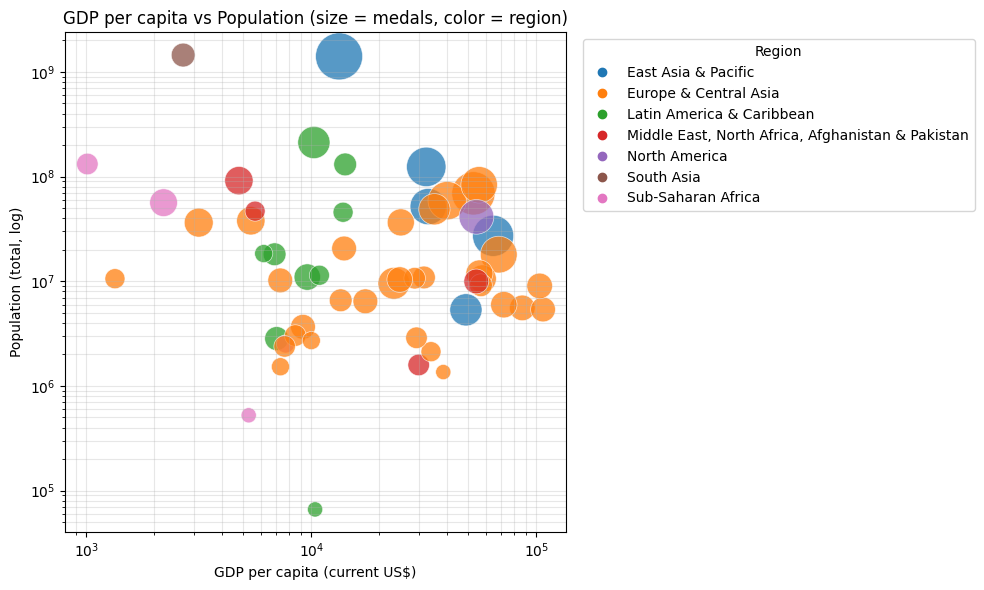

In [37]:

df1 = df.dropna(subset=["gdp_per_capita","population","medals_total","region_name"])
regions = df1["region_name"].astype("category")

colors = plt.cm.tab10(regions.cat.codes % 10)

plt.figure(figsize=(10,6))
s = np.sqrt(df1["medals_total"].values) * 120
plt.scatter(
    df1["gdp_per_capita"], df1["population"],
    s=s, c=colors, alpha=0.75, edgecolors="white", linewidths=0.5
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("Population (total, log)")
plt.title("GDP per capita vs Population (size = medals, color = region)")


cats = list(regions.cat.categories)
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', color=plt.cm.tab10(i % 10), label=lab)
    for i, lab in enumerate(cats)
]
plt.legend(handles=handles, title="Region", bbox_to_anchor=(1.02,1), loc="upper left")


plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig1b_bubble_gdp_pop_better.png", dpi=300)
plt.show()


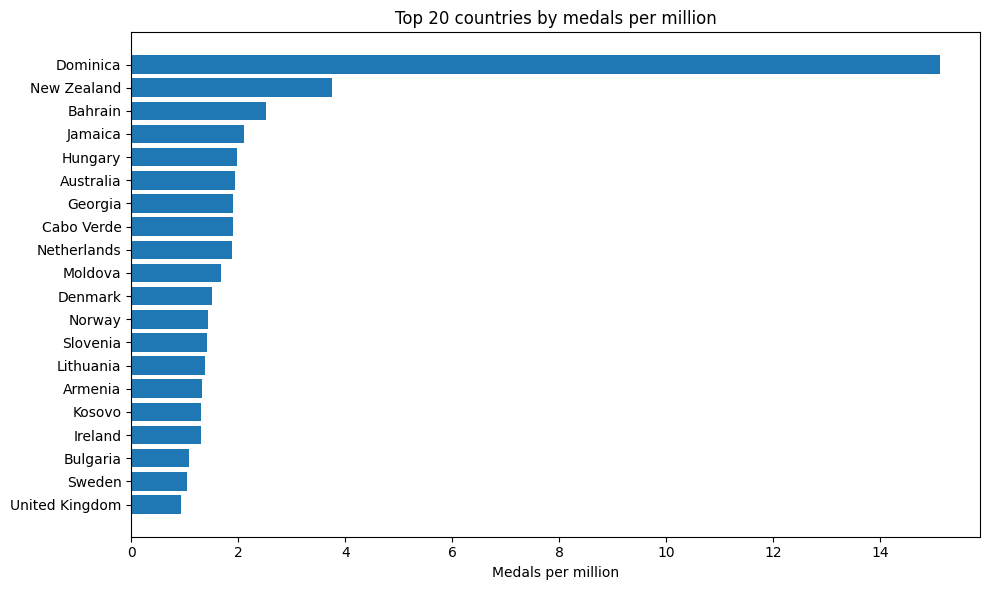

In [ ]:

top = df.sort_values("medals_per_million", ascending=False).head(20)
plt.figure(figsize=(10,6))
plt.barh(top["wb_name"], top["medals_per_million"])
plt.gca().invert_yaxis()
plt.xlabel("Medals per million")
plt.title("Top 20 countries by medals per million")
plt.tight_layout()
plt.savefig("fig2_bar_mppm.png", dpi=200)
plt.show()


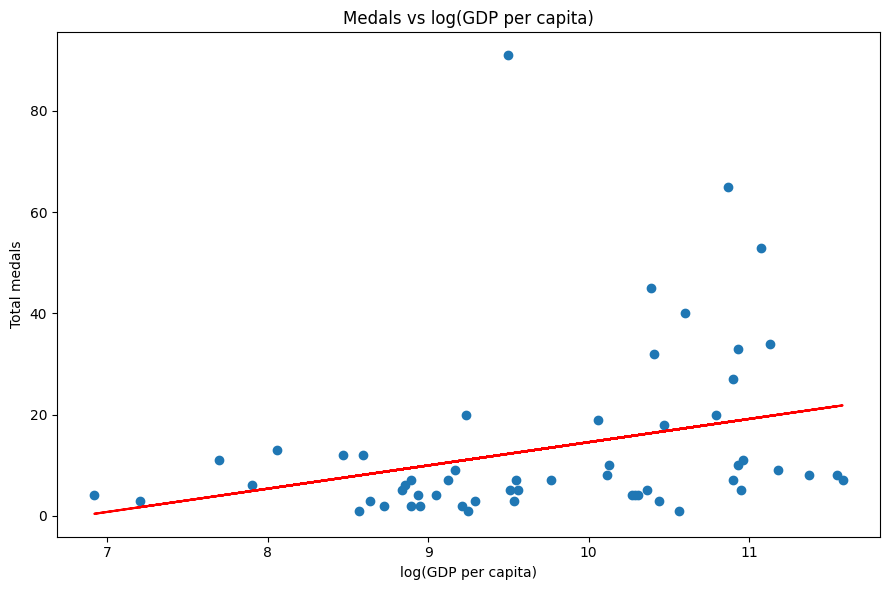

In [ ]:
x = np.log(df["gdp_per_capita"].replace(0,np.nan)).dropna()
y = df.loc[x.index, "medals_total"]
coef = np.polyfit(x, y, 1)
yy = coef[0]*x + coef[1]
plt.figure(figsize=(9,6))
plt.scatter(x, y)
plt.plot(x, yy, color='red')
plt.xlabel("log(GDP per capita)")
plt.ylabel("Total medals")
plt.title("Medals vs log(GDP per capita)")
plt.tight_layout()
plt.savefig("fig3_scatter_reg.png", dpi=200)
plt.show()


## Save Dataset


In [ ]:

df.to_csv("olympics2024_medals_gdp_pop.csv", index=False)
